In [4]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

In [17]:
import cns
import cns.data_utils as cdu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 10)
# set color_map to tab10
color_map = plt.cm.get_cmap('tab10').colors[:10]
plt.rcParams.update({'font.size': 12})

C:\Users\adams\AppData\Local\Temp\ipykernel_14432\1427791538.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [6]:
cns_dfs = {}
for grouping in ["10MB", "5MB", "3MB", "2MB", "1MB", "500KB", "250KB"]:
	samples_df, cns_df = cdu.main_load(grouping)
	cns_dfs[grouping] = cns_df

Text(0.5, 0, 'Poisition on linear genome')

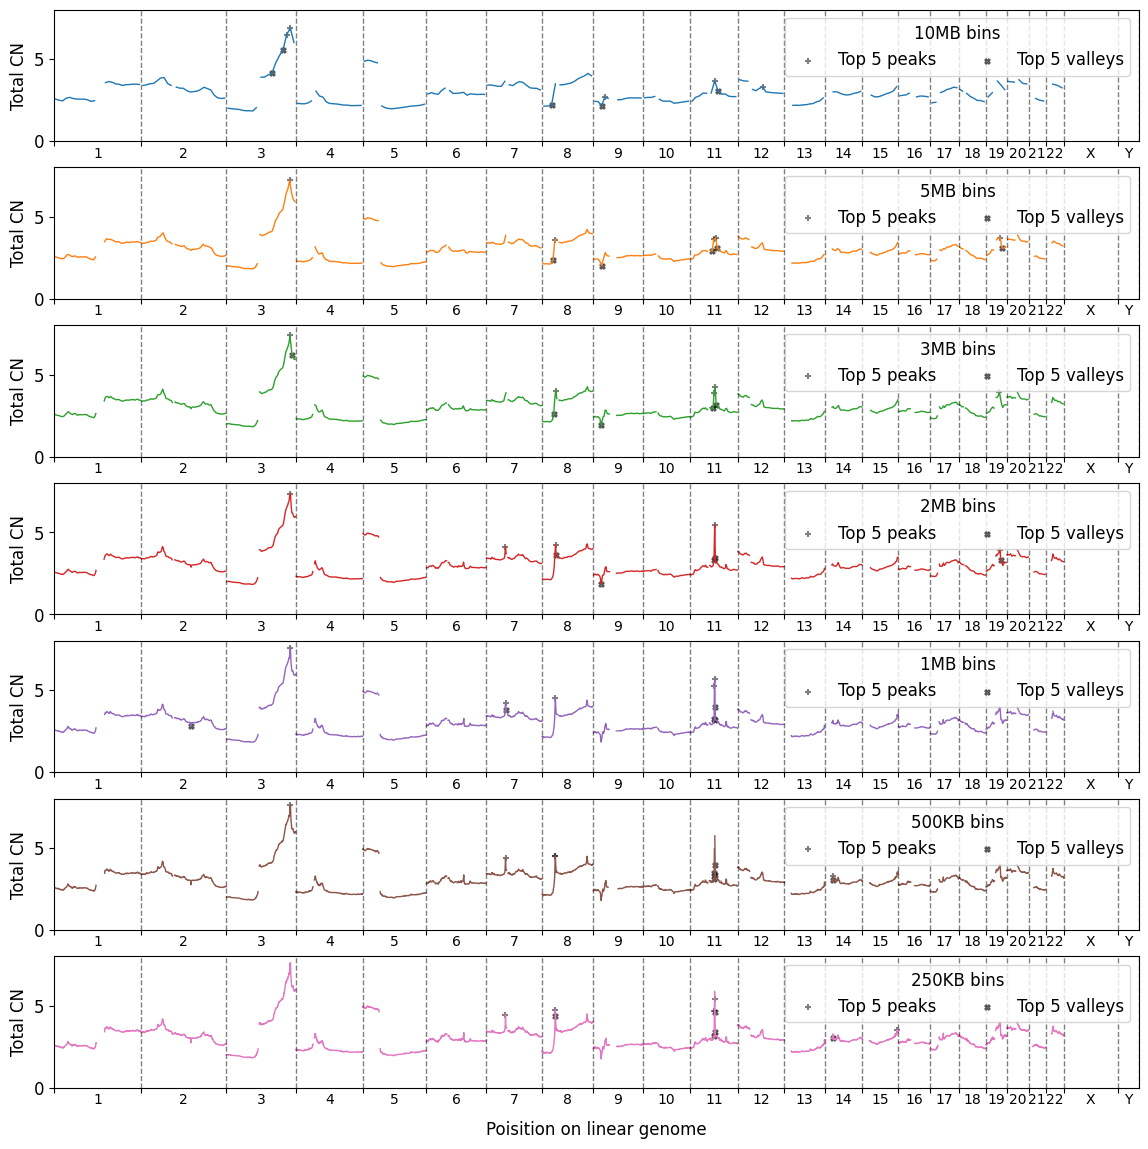

In [7]:
feature = "score"
val_count = 5

fig, axs = plt.subplots(len(cns_dfs), 1, figsize=(14, 14))

for i, (grouping, cns_df) in enumerate(cns_dfs.items()):

	lusc_df = cns.group_samples(cns.only_aut(cns.add_total_cn(cns.select_cns_by_type(cns_df, samples_df, "LUSC"))))
	lusc_df["sample_id"] = "mean LUSC CN"
	lusc_df["score"] = cns.calc_angles(lusc_df, "total_cn")

	cns.plot_lines(axs[i], lusc_df, cn_column="total_cn", color=color_map[i])
	cns.plot_x_lines(axs[i])
	cns.plot_x_ticks(axs[i])

	lusc_df = cns.add_cum_mid(lusc_df)
	lusc_df = lusc_df.sort_values(by="score")
	axs[i].scatter(lusc_df["cum_mid"].head(5), lusc_df["total_cn"].head(5), color="k", alpha=0.5, s=15, label="Top 5 peaks", marker="+")
	axs[i].scatter(lusc_df["cum_mid"].tail(5), lusc_df["total_cn"].tail(5), color="k", alpha=0.5, s=15, label="Top 5 valleys", marker="X")
	axs[i].set_ylim(0, 8)
	axs[i].set_ylabel("Total CN")
	axs[i].legend(title=f"{grouping} bins", loc="upper right", ncol=3)

axs[-1].set_xlabel("Poisition on linear genome")

In [8]:
cosmic = cdu.load_COSMIC()
ensembl = cdu.load_ENSEMBL()

In [9]:
cosmic_means = []
for i, (grouping, cns_df) in enumerate(cns_dfs.items()):
	print(grouping)
	lusc_df = cns.group_samples(cns.only_aut(cns.add_total_cn(cns.select_cns_by_type(cns_df, samples_df, "LUSC"))))
	lusc_df["sample_id"] = "mean LUSC CN"
	lusc_df["score"] = cns.calc_angles(lusc_df, "total_cn")
	cosmic_means.append(cns.mean_value_per_seg(lusc_df, cosmic, "score"))

10MB
5MB
3MB
2MB
1MB
500KB
250KB


In [10]:
ensembl_means = []
for i, (grouping, cns_df) in enumerate(cns_dfs.items()):
	print(grouping)
	lusc_df = cns.group_samples(cns.only_aut(cns.add_total_cn(cns.select_cns_by_type(cns_df, samples_df, "LUSC"))))
	lusc_df["sample_id"] = "mean LUSC CN"
	lusc_df["score"] = cns.calc_angles(lusc_df, "total_cn")
	ensembl_means.append(cns.mean_value_per_seg(lusc_df, ensembl, "score"))

10MB
5MB
3MB
2MB
1MB
500KB
250KB


In [11]:
cosmic_mean = cosmic_means[0].copy()
for vals in cosmic_means[1:]:
	cosmic_mean["score"] += vals["score"]
cosmic_mean["score"] /= len(cosmic_means)
cosmic_mean["total_cn"] = cns.mean_value_per_seg(lusc_df, cosmic, "total_cn")["total_cn"]
print(cosmic_mean.sort_values(by="score", ascending=True).head(10))


     chrom      start        end    name     score  total_cn
114  chr11   70049268   70053496    FADD -1.427664  5.679763
113  chr11   69455854   69469242   CCND1 -1.193919  5.861743
621   chr8   38268655   38326352   FGFR1 -0.756986  4.711992
482   chr3  181429713  181432221    SOX2 -0.649780  7.500447
593   chr7   55086713   55324313    EGFR -0.326905  4.433787
481   chr3  178865901  178957881  PIK3CA -0.295182  6.923450
645   chr8  128747679  128753674     MYC -0.277115  4.476789
657   chr9   35073831   35080013   FANCG -0.236994  2.902800
372   chr2   61108655   61158745     REL -0.233901  4.186584
371   chr2   60678301   60780702  BCL11A -0.233549  4.191277


In [12]:
ensembl_mean = ensembl_means[0].copy()
for vals in ensembl_means[1:]:
	ensembl_mean["score"] += vals["score"]
ensembl_mean["score"] /= len(ensembl_means)
ensembl_mean["total_cn"] = cns.mean_value_per_seg(lusc_df, ensembl, "total_cn")["total_cn"]
print(ensembl_mean.sort_values(by="score", ascending=True).head(10))


      chrom     start       end             name     score  total_cn
3700  chr11  70244509  70282690  ENSG00000085733 -1.448149  5.596533
3699  chr11  70116805  70230509  ENSG00000131626 -1.427664  5.679763
3698  chr11  70049268  70053496  ENSG00000168040 -1.427664  5.679763
3697  chr11  69924407  70035634  ENSG00000131620 -1.402365  5.775067
3696  chr11  69624991  69633792  ENSG00000186895 -1.395732  5.861743
3695  chr11  69587796  69590171  ENSG00000075388 -1.395732  5.861743
3694  chr11  69587253  69587718  ENSG00000268351 -1.395732  5.861743
3688  chr11  68771862  68780877  ENSG00000172935 -1.241064  4.674376
3689  chr11  68816364  68858072  ENSG00000162341 -1.222446  4.875151
3690  chr11  69061604  69182494  ENSG00000172927 -1.193919  3.210811


In [18]:
both_means = pd.merge(cosmic_mean, ensembl_mean, on=["chrom", "start", "end"], suffixes=("_cosmic", "_ensembl"), how="right")
print(both_means.sort_values(by="score_ensembl", ascending=True).head(40))

       chrom      start        end name_cosmic  score_cosmic  total_cn_cosmic  \
3700   chr11   70244509   70282690         NaN           NaN              NaN   
3699   chr11   70116805   70230509         NaN           NaN              NaN   
3698   chr11   70049268   70053496        FADD     -1.427664         5.679763   
3697   chr11   69924407   70035634         NaN           NaN              NaN   
3696   chr11   69624991   69633792         NaN           NaN              NaN   
3695   chr11   69587796   69590171         NaN           NaN              NaN   
3694   chr11   69587253   69587718         NaN           NaN              NaN   
3688   chr11   68771862   68780877         NaN           NaN              NaN   
3689   chr11   68816364   68858072         NaN           NaN              NaN   
3690   chr11   69061604   69182494         NaN           NaN              NaN   
3691   chr11   69455854   69469242       CCND1     -1.193919         5.861743   
3692   chr11   69467843   69

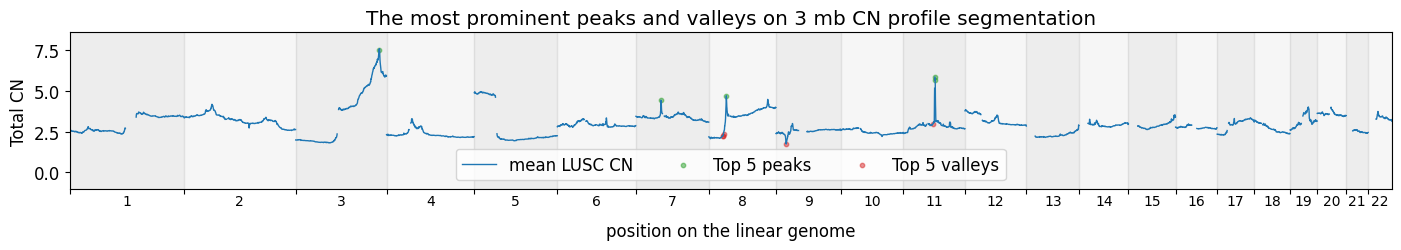

In [14]:
feature = "score"
val_count = 5
# indices of top 5 values

fig, ax = cns.fig_lines(lusc_df, cn_columns="total_cn", colors=color_map[0])
fig.set_size_inches(14, 2)

for i, sel_df in enumerate([cosmic_mean]):
	sel_df = cns.add_cum_mid(sel_df)
	sel_df = sel_df.sort_values(by="score")
	ax.scatter(sel_df["cum_mid"].head(5), sel_df["total_cn"].head(5), color=color_map[2 + i*2], alpha=0.5, s=10, label="Top 5 peaks")
	ax.scatter(sel_df["cum_mid"].tail(5), sel_df["total_cn"].tail(5), color=color_map[3 + i*2], alpha=0.5, s=10, label="Top 5 valleys")

plt.title("The most prominent peaks and valleys on 3 mb CN profile segmentation")
plt.ylabel("Total CN")

# legend with 3 columns
ax.legend(loc="lower center", ncol=6)

cdu.save_cns_fig("3MB_cns_peaks_valleys")

In [16]:
both_means.sort_values(by="score_ensembl", ascending=True).reset_index().query("name_cosmic == 'SOX2'")

,index,chrom,start,end,name_cosmic,score_cosmic,total_cn_cosmic,name_ensembl,score_ensembl,total_cn_ensembl
27,14166,chr3,181429713,181432221,SOX2,-0.64978,7.500447,ENSG00000181449,-0.64978,7.500447
